# PrithviWxC

This notebook will walk you through how to construct the model,
load the weights, build the dataset, and use the model for inference.

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import hf_hub_download, snapshot_download

In [2]:
import sys
print(sys.executable)

/home/gpuuser7/gpuuser7_a/alok/prithvi_workspace/Prithvi-WxC/venv/bin/python


We now configure the backends and torch states, including setting the seeds for the RNGs.

In [3]:
torch.jit.enable_onednn_fusion(True)
if torch.cuda.is_available():
    print(f"Using device: {torch.cuda.get_device_name()}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = True

random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    print('Using GPU for computations')
torch.manual_seed(42)
np.random.seed(42)

Using device: NVIDIA A100-SXM4-80GB
Using GPU for computations


The model has approximately 2.3 billion parameters, so it
requires reasonable computational resources, but it is possible
to run it on a CPU.

In [4]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

## Dataloader
### Variables and times

With the environment ready to go, we now need to set up the task.
The core model expects a fixed set of variables from the MERRA-2
dataset, which are prescribed below. The variables are comprised
of surface variables, surface static variables, and variables at
various vertical levels within the atmosphere. More details on the
MERRA-2 dataset can be found
[here](https://gmao.gsfc.nasa.gov/reanalysis/MERRA-2/).

The MERRA-2 dataset includes data at longitudes of $-180^\circ$
and $+180^\circ$. This represents duplicate data, so we set a
padding variable to remove it.

The input to the core model consists of these variables at two
different times. The time difference in hours between these samples
is passed to the model and set in the input_time variable.

The model's task is to predict the fixed set of variables at a
target time, given the input data.

For example, if the input times are 0900 and 1200, resulting in
an input_time of -3, then a lead_time of 6 would result in a
target time of 1800.

In [5]:
surface_vars = [
    "EFLUX",
    "GWETROOT",
    "HFLUX",
    "LAI",
    "LWGAB",
    "LWGEM",
    "LWTUP",
    "PS",
    "QV2M",
    "SLP",
    "SWGNT",
    "SWTNT",
    "T2M",
    "TQI",
    "TQL",
    "TQV",
    "TS",
    "U10M",
    "V10M",
    "Z0M",
]
static_surface_vars = ["FRACI", "FRLAND", "FROCEAN", "PHIS"]
vertical_vars = ["CLOUD", "H", "OMEGA", "PL", "QI", "QL", "QV", "T", "U", "V"]
levels = [
    34.0,
    39.0,
    41.0,
    43.0,
    44.0,
    45.0,
    48.0,
    51.0,
    53.0,
    56.0,
    63.0,
    68.0,
    71.0,
    72.0,
]
padding = {"level": [0, 0], "lat": [0, -1], "lon": [0, 0]}

lead_times = [18]  # This varibale can be change to change the task
input_times = [-6]  # This varibale can be change to change the task

variable_names = surface_vars + [
    f'{var}_level_{level}' for var in vertical_vars for level in levels
]

### Data file
MERRA-2 data is available from 1980 to the present day,
at 3-hour temporal resolution. The dataloader we have provided
expects the surface data and vertical data to be saved in
separate files, and when provided with the directories, will
search for the relevant data that falls within the provided time range.


In [6]:
time_range = ("2020-01-01T00:00:00", "2020-01-02T05:59:59")

surf_dir = Path("../data/merra-2")
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns="merra-2/MERRA2_sfc_2020010[1].nc",
    local_dir="../data",
)

vert_dir = Path("../data/merra-2")
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns="merra-2/MERRA_pres_2020010[1].nc",
    local_dir="../data",
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

'/home/gpuuser7/gpuuser7_a/alok/prithvi_workspace/Prithvi-WxC/data'

### Climatology
The PrithviWxC model was trained to calculate the output by
producing a perturbation to the climatology at the target time.
 This mode of operation is set via the `residual=climate` option.
 This was chosen as climatology is typically a strong prior for
 long-range prediction. When using the `residual=climate` option,
 we have to provide the dataloader with the path of the
 climatology data.

In [7]:
surf_clim_dir = Path("../data/climatology")
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns="climatology/climate_surface_doy00[1]*.nc",
    local_dir="../data",
)

vert_clim_dir = Path("../data/climatology")
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns="climatology/climate_vertical_doy00[1]*.nc",
    local_dir="../data",
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

'/home/gpuuser7/gpuuser7_a/alok/prithvi_workspace/Prithvi-WxC/data'

### Postion encoding
Position data is included in the data passed to the model,
as this allows the attention mechanism to determine data
locality rather than explicit or implicit data connections.
The position data is encoded in the model with two possible
options, fourier or absolute. As these encoding options
require different treatment within the data loader, the
chosen option is set here.

In [8]:
positional_encoding = "fourier"

### Dataset init
We can now instantiate the MERRA2 Dataset class provided.

In [9]:
from PrithviWxC.dataloaders.merra2 import Merra2Dataset

dataset = Merra2Dataset(
    time_range=time_range,
    lead_times=lead_times,
    input_times=input_times,
    data_path_surface=surf_dir,
    data_path_vertical=vert_dir,
    climatology_path_surface=surf_clim_dir,
    climatology_path_vertical=vert_clim_dir,
    surface_vars=surface_vars,
    static_surface_vars=static_surface_vars,
    vertical_vars=vertical_vars,
    levels=levels,
    positional_encoding=positional_encoding,
)
assert len(dataset) > 0, "There doesn't seem to be any valid data."

## The model
We are now ready to build the mdoel.
### Scalers
Additionally, the model takes as static parameters the mean
and variance values of the input variables and the variance
values of the target difference, i.e., the variance between
climatology and instantaneous variables. We have provided
data files containing these values, and here we load this data.

In [10]:
from PrithviWxC.dataloaders.merra2 import (
    input_scalers,
    output_scalers,
    static_input_scalers,
)

surf_in_scal_path = Path("../data/climatology/musigma_surface.nc")
hf_hub_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    filename=f"climatology/{surf_in_scal_path.name}",
    local_dir="../data",
)

vert_in_scal_path = Path("../data/climatology/musigma_vertical.nc")
hf_hub_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    filename=f"climatology/{vert_in_scal_path.name}",
    local_dir="../data",
)

surf_out_scal_path = Path("../data/climatology/anomaly_variance_surface.nc")
hf_hub_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    filename=f"climatology/{surf_out_scal_path.name}",
    local_dir="../data",
)

vert_out_scal_path = Path("../data/climatology/anomaly_variance_vertical.nc")
hf_hub_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    filename=f"climatology/{vert_out_scal_path.name}",
    local_dir="../data",
)

in_mu, in_sig = input_scalers(
    surface_vars,
    vertical_vars,
    levels,
    surf_in_scal_path,
    vert_in_scal_path,
)

output_sig = output_scalers(
    surface_vars,
    vertical_vars,
    levels,
    surf_out_scal_path,
    vert_out_scal_path,
)

static_mu, static_sig = static_input_scalers(
    surf_in_scal_path,
    static_surface_vars,
)

### Task and additional configs
As previously mentioned, the PrithviWxC model's pretext task
involved predicting the desired variable at a specific lead
time. This was achieved by calculating the difference (delta)
compared to the climatological average at that time. This
operational mode is activated using the residual flag. Although
the model includes additional residual options, the core model
weights were not trained using these modes.

Additionally, for training and evaluation, it is possible to
mask tokens in the model. The masking occurs after tokenization,
prior to the encoder layers. The model utilizes multi-axis
attention, with data broken down into a hierarchy of local and
global patches. Consequently, masking can be configured to mask
either small local patches or larger global patches. This
configuration is achieved via the `masking_mode` flag. It is
possible to set `masking_mode=both`. This does not mix the modes
but rather allows both modes to be used and swapped between,
primarily for training purposes. For this demonstration, we will
adjust the masking ratio to showcase the reconstruction
capabilities of the model.

Finally, we can set up shifting. Primarily utilized in the
decoder, this enables alternate shifting of the attention
windows, similar to the SWIN model. This option necessitates
an even number of decoder blocks and is incompatible with the
encoder when masking is also employed.

In [11]:
residual = "climate"
masking_mode = "global"
encoder_shifting = True
decoder_shifting = True
masking_ratio = 0.0

### Model init
We now have all the pieces to build the model. If you are
using the pretrained weights, a number of the model
hyperparameters are predetermined and included below. With
this configuration, the model will have approximately 2.3
billion parameters. Therefore, if you want to train the fully
unfrozen model, you will likely need to use a model distribution
approach, such as fully shared data parallelism (FSDP). To
further reduce the memory usage of the model when gradients are
required, there are two variables — `checkpoint_encoder` and
`checkpoint_decoder` — which enable activation checkpointing of
desired transformer layers.

In [12]:
import yaml

from PrithviWxC.model import PrithviWxC

hf_hub_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    filename="config.yaml",
    local_dir="../data",
)

with open("../data/config.yaml", "r") as f:
    config = yaml.safe_load(f)

model = PrithviWxC(
    in_channels=config["params"]["in_channels"],
    input_size_time=config["params"]["input_size_time"],
    in_channels_static=config["params"]["in_channels_static"],
    input_scalers_mu=in_mu,
    input_scalers_sigma=in_sig,
    input_scalers_epsilon=config["params"]["input_scalers_epsilon"],
    static_input_scalers_mu=static_mu,
    static_input_scalers_sigma=static_sig,
    static_input_scalers_epsilon=config["params"][
        "static_input_scalers_epsilon"
    ],
    output_scalers=output_sig**0.5,
    n_lats_px=config["params"]["n_lats_px"],
    n_lons_px=config["params"]["n_lons_px"],
    patch_size_px=config["params"]["patch_size_px"],
    mask_unit_size_px=config["params"]["mask_unit_size_px"],
    mask_ratio_inputs=masking_ratio,
    mask_ratio_targets=0.0,
    embed_dim=config["params"]["embed_dim"],
    n_blocks_encoder=config["params"]["n_blocks_encoder"],
    n_blocks_decoder=config["params"]["n_blocks_decoder"],
    mlp_multiplier=config["params"]["mlp_multiplier"],
    n_heads=config["params"]["n_heads"],
    dropout=config["params"]["dropout"],
    drop_path=config["params"]["drop_path"],
    parameter_dropout=config["params"]["parameter_dropout"],
    residual=residual,
    masking_mode=masking_mode,
    encoder_shifting=encoder_shifting,
    decoder_shifting=decoder_shifting,
    positional_encoding=positional_encoding,
    checkpoint_encoder=[],
    checkpoint_decoder=[],
)

### Load weights
We have provided unshared pretrained weights for the model,
which can now be loaded. The model can then be transferred
to the requested device.

In [13]:
weights_path = Path("../data/weights/prithvi.wxc.2300m.v1.pt")
# hf_hub_download(
#     repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
#     filename=weights_path.name,
#     local_dir="../data/weights",
# )

state_dict = torch.load(weights_path, weights_only=False)
if "model_state" in state_dict:
    state_dict = state_dict["model_state"]
model.load_state_dict(state_dict, strict=True)

if (hasattr(model, "device") and model.device != device) or not hasattr(
    model, "device"
):
    model = model.to(device)

## Inference
We are now ready to perform inference on the model. The data
returned from the dataset class requires additional
preprocessing; therefore, after polling the dataset, we process
the data using the `preproc` function. This processed data is
then transferred to the device. To recover the masking, we can
save the torch RNG state and use it later. Finally, we run the
model in evaluation mode without generating the gradient graph.

In [14]:
from PrithviWxC.dataloaders.merra2 import preproc

data = next(iter(dataset))
batch = preproc([data], padding)

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

rng_state_1 = torch.get_rng_state()
with torch.no_grad():
    model.eval()
    out = model(batch)

/home/gpuuser7/gpuuser7_a/miniconda3/envs/alok/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


In [15]:
t2m = out[0, variable_names.index("T2M"), :, :].cpu().numpy()
t2m[120]

array([293.59415, 293.50897, 293.5353 , 293.459  , 293.8272 , 293.7378 ,
       293.76486, 293.95892, 294.16385, 294.20474, 294.22702, 294.30264,
       294.4081 , 294.44095, 294.4464 , 294.439  , 294.41165, 294.5209 ,
       294.479  , 294.56128, 294.8465 , 294.92737, 295.03867, 294.97977,
       294.81262, 294.65295, 294.6326 , 294.59097, 294.50745, 294.36423,
       294.14612, 294.07144, 293.89722, 294.00497, 293.96622, 294.06723,
       293.984  , 293.76178, 293.79855, 294.00168, 294.09802, 294.3547 ,
       294.6636 , 294.79855, 294.89517, 294.75256, 294.46115, 294.42502,
       294.54727, 294.64346, 295.143  , 295.4107 , 295.771  , 296.08914,
       295.97632, 296.01147, 295.88068, 295.881  , 295.79355, 295.77884,
       295.4619 , 295.40955, 295.3995 , 295.5355 , 295.6162 , 295.80276,
       295.56366, 295.40662, 294.84488, 294.7818 , 294.3706 , 294.54837,
       294.5604 , 294.6298 , 294.65332, 294.63843, 294.38177, 294.5079 ,
       294.3474 , 294.3226 , 294.26224, 294.31143, 

## Plotting

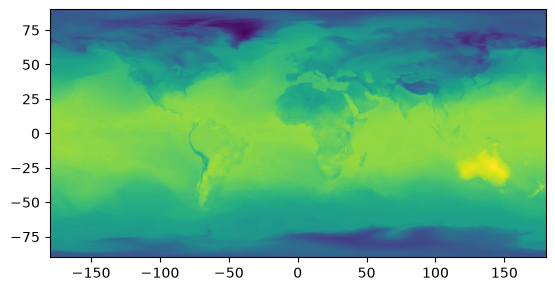

In [16]:
t2m = out[0, variable_names.index("T2M")].cpu().numpy()

lat = np.linspace(-90, 90, out.shape[-2])
lon = np.linspace(-180, 180, out.shape[-1])
X, Y = np.meshgrid(lon, lat)

plt.contourf(X, Y, t2m, 100)
plt.gca().set_aspect("equal")
plt.show()

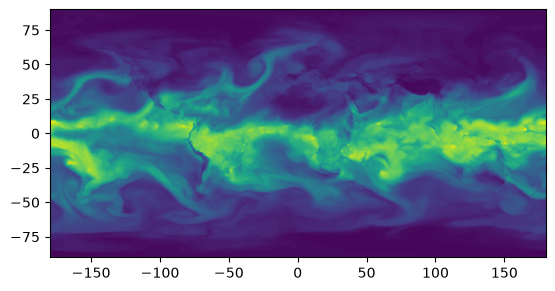

In [17]:
tqv = out[0, variable_names.index("TQV")].cpu().numpy()

lat = np.linspace(-90, 90, out.shape[-2])
lon = np.linspace(-180, 180, out.shape[-1])
X, Y = np.meshgrid(lon, lat)

plt.contourf(X, Y, tqv, 100)
plt.gca().set_aspect("equal")
plt.show()

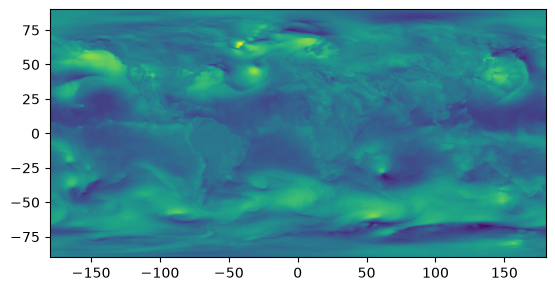

In [18]:
u10m = out[0, variable_names.index("U10M")].cpu().numpy()

lat = np.linspace(-90, 90, out.shape[-2])
lon = np.linspace(-180, 180, out.shape[-1])
X, Y = np.meshgrid(lon, lat)

plt.contourf(X, Y, u10m, 100)
plt.gca().set_aspect("equal")
plt.show()

In [19]:
import torch

def inspect_model_weights(file_path):
    print(f"Loading weights from: {file_path}\n")
    
    try:
        # map_location='cpu' ensures it loads even if saved on a GPU
        # Note: weights_only=False is used here because full checkpoints 
        # (with optimizer states) often contain non-tensor Python objects.
        model_data = torch.load(file_path, map_location='cpu', weights_only=False)
    except Exception as e:
        print(f"Error loading the .pt file: {e}")
        return

    # Extract the actual weights dictionary
    if isinstance(model_data, dict):
        if 'model_state' in model_data:
            print("Detected full checkpoint. Extracting 'model_state'...\n")
            state_dict = model_data['model_state']
        elif 'state_dict' in model_data:
            print("Detected full checkpoint. Extracting 'state_dict'...\n")
            state_dict = model_data['state_dict']
        elif 'model_state_dict' in model_data:
            print("Detected full checkpoint. Extracting 'model_state_dict'...\n")
            state_dict = model_data['model_state_dict']
        else:
            # Assume the dictionary itself is the state_dict
            state_dict = model_data
    else:
        # If the whole model object was saved instead of just weights
        if hasattr(model_data, 'state_dict'):
            state_dict = model_data.state_dict()
        else:
            print("Could not extract a state dictionary from the provided file.")
            return

    # Print a formatted table header
    print(f"{'Layer Name':<50} | {'Precision (dtype)':<15} | {'Shape'}")
    print("-" * 95)

    # Iterate through parameters and extract metadata
    tensor_count = 0
    for name, param in state_dict.items():
        if isinstance(param, torch.Tensor):
            dtype = str(param.dtype).replace('torch.', '')
            shape = list(param.shape)
            print(f"{name:<50} | {dtype:<15} | {shape}")
            tensor_count += 1
        else:
            # Catch cases where a non-tensor is stored in the state dict
            print(f"{name:<50} | {type(param).__name__:<15} | Not a Tensor")
            
    print("-" * 95)
    print(f"Total tensor layers found: {tensor_count}")

if __name__ == "__main__":
    # Replace with the path to your actual model file
    model_path = "/home/gpuuser7/gpuuser7_a/alok/prithvi_workspace/Prithvi-WxC/data/weights/prithvi.wxc.2300m.v1.pt"
    inspect_model_weights(model_path)

Loading weights from: /home/gpuuser7/gpuuser7_a/alok/prithvi_workspace/Prithvi-WxC/data/weights/prithvi.wxc.2300m.v1.pt

Detected full checkpoint. Extracting 'model_state'...

Layer Name                                         | Precision (dtype) | Shape
-----------------------------------------------------------------------------------------------
mask_token                                         | float32         | [1, 1, 1, 2560]
input_scalers_mu                                   | float32         | [1, 1, 160, 1, 1]
input_scalers_sigma                                | float32         | [1, 1, 160, 1, 1]
static_input_scalers_mu                            | float32         | [1, 11, 1, 1]
static_input_scalers_sigma                         | float32         | [1, 11, 1, 1]
output_scalers                                     | float32         | [1, 160, 1, 1]
patch_embedding.proj.weight                        | float32         | [2560, 320, 2, 2]
patch_embedding.proj.bias              

In [20]:
import torch
from pathlib import Path

original_weights_path = Path("../data/weights/prithvi.wxc.2300m.v1.pt")
inference_weights_path = Path("../data/weights/prithvi_inference_only.pt")

print(f"Loading heavy checkpoint from: {original_weights_path}")
checkpoint = torch.load(original_weights_path, map_location='cpu', weights_only=False)

if "model_state" in checkpoint:
    print("Extracting 'model_state'...")
    weights_only = checkpoint["model_state"]
    
    # Save the stripped-down weights
    torch.save(weights_only, inference_weights_path)
    print(f"Successfully saved inference-only weights to: {inference_weights_path}")
else:
    print("Could not find 'model_state' in the checkpoint.")

Loading heavy checkpoint from: ../data/weights/prithvi.wxc.2300m.v1.pt
Extracting 'model_state'...
Successfully saved inference-only weights to: ../data/weights/prithvi_inference_only.pt


In [21]:
from PrithviWxC.dataloaders.merra2 import preproc

# 1. Load the new lightweight weights safely
print("Loading lightweight inference weights...")
state_dict = torch.load(inference_weights_path, map_location='cpu', weights_only=True)
model.load_state_dict(state_dict, strict=True)

if (hasattr(model, "device") and model.device != device) or not hasattr(model, "device"):
    model = model.to(device)

# 2. Setup the batch
data = next(iter(dataset))
batch = preproc([data], padding)

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

# 3. Perform Inference
rng_state_1 = torch.get_rng_state()
print("Running inference...")

with torch.no_grad():
    model.eval()
    out = model(batch)

print("Inference complete!")

Loading lightweight inference weights...
Running inference...
Inference complete!


In [22]:
import torch

def check_weight_ranges(file_path):
    print(f"Loading weights from: {file_path}...\n")
    
    try:
        # Load the inference-only file safely
        state_dict = torch.load(file_path, map_location='cpu', weights_only=True)
    except Exception as e:
        print(f"Error loading file: {e}")
        return
        
    global_min = float('inf')
    global_max = float('-inf')
    min_layer = ""
    max_layer = ""
    
    tensor_count = 0
    
    print("Scanning tensors for value ranges. This might take a moment for large models...")
    
    for name, tensor in state_dict.items():
        if isinstance(tensor, torch.Tensor) and tensor.numel() > 0:
            tensor_count += 1
            
            # Extract the min and max for the current tensor
            t_min = float(tensor.min())
            t_max = float(tensor.max())
            
            # Update global minimum
            if t_min < global_min:
                global_min = t_min
                min_layer = name
                
            # Update global maximum
            if t_max > global_max:
                global_max = t_max
                max_layer = name

    # Output the results
    print("\n" + "=" * 80)
    print(f"{'WEIGHT RANGE ANALYSIS':^80}")
    print("=" * 80)
    print(f"Total Tensors Scanned : {tensor_count:,}")
    print("-" * 80)
    print(f"Overall Minimum Value : {global_min:.6f}")
    print(f"Located in Layer      : {min_layer}")
    print("-" * 80)
    print(f"Overall Maximum Value : {global_max:.6f}")
    print(f"Located in Layer      : {max_layer}")
    print("=" * 80)

if __name__ == "__main__":
    # Replace with your actual file path if different
    # For example: "../data/weights/prithvi_inference_only.pt"
    inference_weights_path = "/home/gpuuser7/gpuuser7_a/alok/prithvi_workspace/Prithvi-WxC/data/weights/prithvi_inference_only.pt" 
    check_weight_ranges(inference_weights_path)

Loading weights from: /home/gpuuser7/gpuuser7_a/alok/prithvi_workspace/Prithvi-WxC/data/weights/prithvi_inference_only.pt...

Scanning tensors for value ranges. This might take a moment for large models...

                             WEIGHT RANGE ANALYSIS                              
Total Tensors Scanned : 320
--------------------------------------------------------------------------------
Overall Minimum Value : -3.665358
Located in Layer      : mask_token
--------------------------------------------------------------------------------
Overall Maximum Value : 100841.023438
Located in Layer      : input_scalers_mu


In [23]:
import torch

# Define paths
input_weights_path = "../data/weights/prithvi_inference_only.pt"
mixed_weights_path = "../data/weights/prithvi_mixed_precision.pt"

print(f"Loading weights from: {input_weights_path}")
state_dict = torch.load(input_weights_path, map_location='cpu', weights_only=True)

mixed_state_dict = {}
fp16_count = 0
fp32_count = 0

# The absolute max for float16 is 65504. We use 65500 as a safe boundary.
FP16_MAX = 65500.0
FP16_MIN = -65500.0

print("Converting eligible layers to float16...")

for name, tensor in state_dict.items():
    # Only evaluate floating-point tensors (ignore integers, booleans, etc.)
    if tensor.is_floating_point() and tensor.numel() > 0:
        t_min = float(tensor.min())
        t_max = float(tensor.max())
        
        # If the values are safely within the float16 range, convert them
        if t_min >= FP16_MIN and t_max <= FP16_MAX:
            mixed_state_dict[name] = tensor.to(torch.float16)
            fp16_count += 1
        else:
            # Leave out-of-bounds tensors (like scalers) as float32
            mixed_state_dict[name] = tensor
            fp32_count += 1
            print(f"  -> Kept {name} in float32 (Range: {t_min:.2f} to {t_max:.2f})")
    else:
        mixed_state_dict[name] = tensor

# Save the new mixed-precision dictionary
torch.save(mixed_state_dict, mixed_weights_path)

print("-" * 60)
print(f"Conversion Complete!")
print(f"Converted {fp16_count} layers to FP16.")
print(f"Kept {fp32_count} layers in FP32.")
print(f"Saved mixed-precision weights to: {mixed_weights_path}")

Loading weights from: ../data/weights/prithvi_inference_only.pt
Converting eligible layers to float16...
  -> Kept input_scalers_mu in float32 (Range: -0.05 to 100841.02)
------------------------------------------------------------
Conversion Complete!
Converted 315 layers to FP16.
Kept 1 layers in FP32.
Saved mixed-precision weights to: ../data/weights/prithvi_mixed_precision.pt


In [24]:
from PrithviWxC.dataloaders.merra2 import preproc
from torch.amp import autocast

print("Loading mixed-precision weights...")
# Load the selectively quantized weights
state_dict = torch.load(mixed_weights_path, map_location='cpu', weights_only=True)

# assign=True ensures the model adopts the exact fp16/fp32 layout from the file
model.load_state_dict(state_dict, strict=True, assign=True)

if (hasattr(model, "device") and model.device != device) or not hasattr(model, "device"):
    model = model.to(device)

# Prepare the batch data
data = next(iter(dataset))
batch = preproc([data], padding)

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

rng_state_1 = torch.get_rng_state()
print("Running mixed-precision inference...")

# Use autocast to automatically handle dtype routing during the forward pass
with torch.no_grad():
    model.eval()
    with autocast(device_type='cuda', dtype=torch.float16):
        out = model(batch)

print("Inference complete!")

Loading mixed-precision weights...
Running mixed-precision inference...
Inference complete!


In [ ]:
import torch
import numpy as np
import pandas as pd
from torch.amp import autocast

# Define paths (ensure these match your saved filenames)
fp32_weights_path = "/home/gpuuser7/gpuuser7_a/alok/prithvi_workspace/Prithvi-WxC/data/weights/prithvi_inference_only.pt"
mixed_weights_path = "/home/gpuuser7/gpuuser7_a/alok/prithvi_workspace/Prithvi-WxC/data/weights/prithvi_mixed_precision_f32_f16.pt"

print("--- Step 1: Running FP32 Baseline Inference ---")
model.load_state_dict(torch.load(fp32_weights_path, map_location='cpu', weights_only=True), strict=True, assign=True)
model = model.to(device)

with torch.no_grad():
    model.eval()
    # Assuming `batch` is already defined in notebook's memory
    out_fp32 = model(batch).cpu().numpy()

print("--- Step 2: Running Mixed-Precision Inference ---")
model.load_state_dict(torch.load(mixed_weights_path, map_location='cpu', weights_only=True), strict=True, assign=True)
model = model.to(device)

with torch.no_grad():
    model.eval()
    with autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.float16):
        out_mp = model(batch).cpu().numpy()

print("--- Step 3: Calculating Precision Loss Metrics ---\n")

results = []

# Iterate through every atmospheric variable
# The output tensor shape is [batch_size, num_variables, lat, lon]
for i, var_name in enumerate(variable_names):
    var_fp32 = out_fp32[0, i]
    var_mp = out_mp[0, i]
    
    # Calculate regression metrics
    mae = np.mean(np.abs(var_fp32 - var_mp))
    rmse = np.sqrt(np.mean((var_fp32 - var_mp)**2))
    max_diff = np.max(np.abs(var_fp32 - var_mp))
    
    results.append({
        "Variable": var_name,
        "MAE": mae,
        "RMSE": rmse,
        "Max Diff": max_diff
    })

# Calculate global metrics across the entire output tensor
global_mae = np.mean(np.abs(out_fp32 - out_mp))
global_rmse = np.sqrt(np.mean((out_fp32 - out_mp)**2))
global_max_diff = np.max(np.abs(out_fp32 - out_mp))

print(f"OVERALL MODEL DIFFERENCE")
print("=" * 40)
print(f"Global MAE      : {global_mae:.6f}")
print(f"Global RMSE     : {global_rmse:.6f}")
print(f"Global Max Diff : {global_max_diff:.6f}\n")

# Display the 15 variables most impacted by the precision conversion
df_results = pd.DataFrame(results)
print("TOP 15 VARIABLES WITH HIGHEST RMSE DEVIATION")
print("=" * 60)
print(df_results.sort_values(by="RMSE", ascending=False).head(15).to_string(index=False))

--- Step 1: Running FP32 Baseline Inference ---
--- Step 2: Running Mixed-Precision Inference ---
--- Step 3: Calculating Precision Loss Metrics ---

OVERALL MODEL DIFFERENCE
Global MAE      : 1.820357
Global RMSE     : 8.251835
Global Max Diff : 353.968750

TOP 15 VARIABLES WITH HIGHEST RMSE DEVIATION
     Variable       MAE      RMSE   Max Diff
          SLP 31.625893 43.929806 353.968750
           PS 29.162056 40.249561 347.679688
PL_level_72.0 28.955559 39.977234 343.953125
PL_level_71.0 28.411432 39.218239 339.289062
PL_level_68.0 26.538301 36.632500 316.742188
PL_level_63.0 23.409372 32.316158 279.531250
PL_level_56.0 17.448765 24.087578 207.828125
PL_level_53.0 13.689972 18.897976 163.164062
PL_level_51.0 10.733870 14.817952 127.503906
        SWGNT  5.048129 12.684762 254.825409
        SWTNT  4.673366 11.636065 225.487122
PL_level_48.0  6.519624  9.001330  77.472656
 H_level_44.0  3.905078  5.453739  45.020508
 H_level_45.0  3.777018  5.372215  51.426758
 H_level_43.0  3.8447

In [ ]:
import torch
import numpy as np
import pandas as pd
from torch.amp import autocast

# Define paths (ensure these match your saved filenames)
fp32_weights_path = "../data/weights/prithvi_inference_only.pt"
mixed_weights_path = "../data/weights/prithvi_mixed_precision.pt"

print("--- Step 1: Running FP32 Baseline Inference ---")
model.load_state_dict(torch.load(fp32_weights_path, map_location='cpu', weights_only=True), strict=True, assign=True)
model = model.to(device)

with torch.no_grad():
    model.eval()
    # Assuming `batch` is already defined in your notebook's memory
    out_fp32 = model(batch).cpu().numpy()

print("--- Step 2: Running Mixed-Precision Inference ---")
model.load_state_dict(torch.load(mixed_weights_path, map_location='cpu', weights_only=True), strict=True, assign=True)
model = model.to(device)

with torch.no_grad():
    model.eval()
    with autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.float16):
        out_mp = model(batch).cpu().numpy()

print("--- Step 3: Calculating Precision Loss Metrics ---\n")

results = []

# Iterate through every atmospheric variable
# The output tensor shape is [batch_size, num_variables, lat, lon]
for i, var_name in enumerate(variable_names):
    var_fp32 = out_fp32[0, i]
    var_mp = out_mp[0, i]
    
    # Calculate regression metrics
    mae = np.mean(np.abs(var_fp32 - var_mp))
    rmse = np.sqrt(np.mean((var_fp32 - var_mp)**2))
    max_diff = np.max(np.abs(var_fp32 - var_mp))
    
    results.append({
        "Variable": var_name,
        "MAE": mae,
        "RMSE": rmse,
        "Max Diff": max_diff
    })

# Calculate global metrics across the entire output tensor
global_mae = np.mean(np.abs(out_fp32 - out_mp))
global_rmse = np.sqrt(np.mean((out_fp32 - out_mp)**2))
global_max_diff = np.max(np.abs(out_fp32 - out_mp))

print(f"OVERALL MODEL DIFFERENCE")
print("=" * 40)
print(f"Global MAE      : {global_mae:.6f}")
print(f"Global RMSE     : {global_rmse:.6f}")
print(f"Global Max Diff : {global_max_diff:.6f}\n")

# Display the 15 variables most impacted by the precision conversion
df_results = pd.DataFrame(results)
print("TOP 15 VARIABLES WITH HIGHEST RMSE DEVIATION")
print("=" * 60)
print(df_results.sort_values(by="RMSE", ascending=False).head(15).to_string(index=False))

--- Step 1: Running FP32 Baseline Inference ---


/home/gpuuser7/gpuuser7_a/miniconda3/envs/alok/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


--- Step 2: Running Mixed-Precision Inference ---
--- Step 3: Calculating Precision Loss Metrics ---

OVERALL MODEL DIFFERENCE
Global MAE      : 1.879461
Global RMSE     : 8.202843
Global Max Diff : 276.632812

TOP 15 VARIABLES WITH HIGHEST RMSE DEVIATION
     Variable       MAE      RMSE   Max Diff
          SLP 32.601761 43.113041 276.007812
           PS 30.402132 40.158878 276.632812
PL_level_72.0 30.207981 39.896805 274.070312
PL_level_71.0 29.634348 39.144562 270.539062
PL_level_68.0 27.668596 36.546677 252.593750
PL_level_63.0 24.412857 32.237736 220.664062
PL_level_56.0 18.196686 24.027355 166.117188
PL_level_53.0 14.275198 18.856323 127.410156
PL_level_51.0 11.195683 14.782477 100.523438
        SWGNT  4.977535 12.067171 219.908112
        SWTNT  4.640878 11.175399 188.944458
PL_level_48.0  6.801302  8.980565  60.855469
 H_level_44.0  3.969796  5.562043  38.717773
 H_level_43.0  3.953059  5.535221  37.145508
        LWTUP  3.003749  5.337436  67.628723


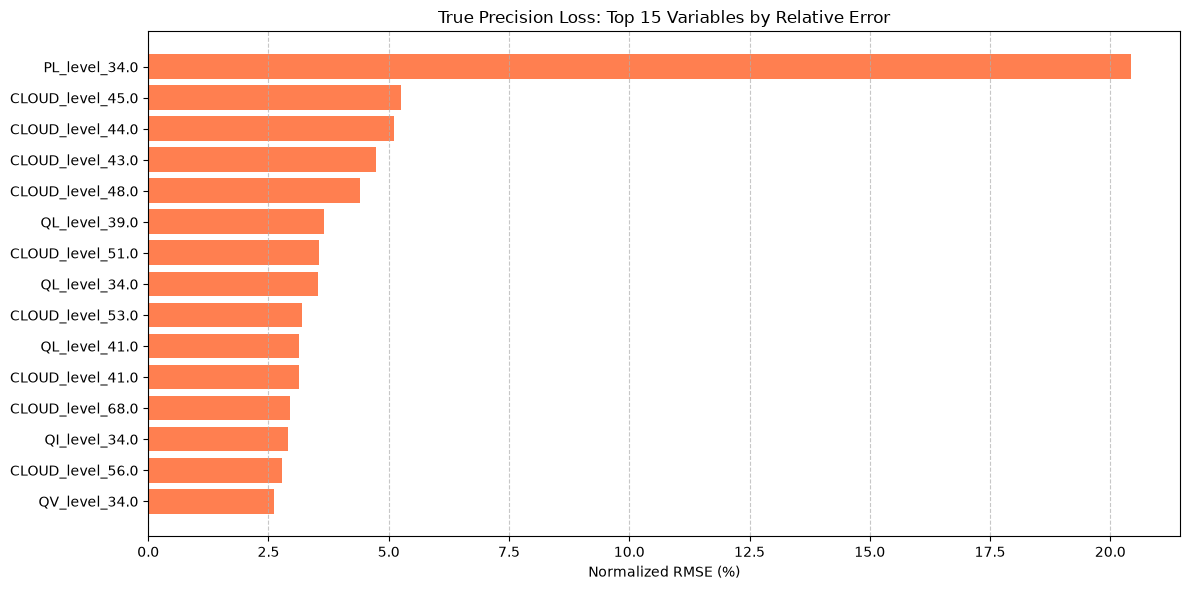

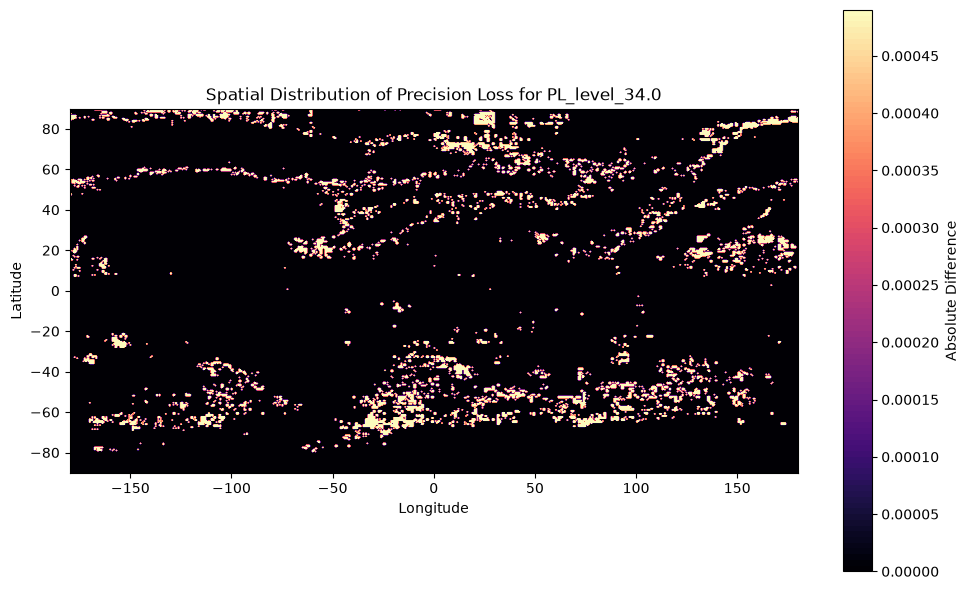

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate Normalized RMSE (NRMSE) for fair comparison
relative_results = []

for i, var_name in enumerate(variable_names):
    var_fp32 = out_fp32[0, i]
    var_mp = out_mp[0, i]
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean((var_fp32 - var_mp)**2))
    
    # Normalize by the range of the actual FP32 values
    var_range = np.max(var_fp32) - np.min(var_fp32)
    
    # Avoid division by zero for uniform fields
    nrmse = (rmse / var_range) * 100 if var_range > 0 else 0 
    
    relative_results.append({
        "Variable": var_name,
        "RMSE (Raw)": rmse,
        "NRMSE (%)": nrmse
    })

df_rel = pd.DataFrame(relative_results)
df_rel_sorted = df_rel.sort_values(by="NRMSE (%)", ascending=False).head(15)

# 2. Plot 1: Top 15 Variables by Normalized Error
plt.figure(figsize=(12, 6))
plt.barh(df_rel_sorted["Variable"][::-1], df_rel_sorted["NRMSE (%)"][::-1], color='coral')
plt.xlabel('Normalized RMSE (%)')
plt.title('True Precision Loss: Top 15 Variables by Relative Error')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Plot 2: Spatial Heatmap of the Worst Offender
# Get the name of the variable with the highest NRMSE
worst_var_name = df_rel_sorted.iloc[0]["Variable"]
worst_var_idx = variable_names.index(worst_var_name)

# Calculate spatial absolute difference
spatial_diff = np.abs(out_fp32[0, worst_var_idx] - out_mp[0, worst_var_idx])

lat = np.linspace(-90, 90, out_fp32.shape[-2])
lon = np.linspace(-180, 180, out_fp32.shape[-1])
X, Y = np.meshgrid(lon, lat)

plt.figure(figsize=(10, 6))
contour = plt.contourf(X, Y, spatial_diff, 100, cmap='magma')
plt.colorbar(contour, label='Absolute Difference')
plt.gca().set_aspect("equal")
plt.title(f'Spatial Distribution of Precision Loss for {worst_var_name}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

TOP 15 VARIABLES WITH HIGHEST NRMSE (%) AND THEIR DATA RANGES
        Variable  Min Value  Max Value  Range  RMSE (Raw)  NRMSE (%)
   PL_level_34.0  5201.5908  5201.5913 0.0005      0.0001    20.4278
CLOUD_level_45.0    -0.0958     1.0071 1.1028      0.0580     5.2620
CLOUD_level_44.0    -0.0773     1.0440 1.1213      0.0573     5.1092
CLOUD_level_43.0    -0.0808     1.0104 1.0911      0.0516     4.7306
CLOUD_level_48.0    -0.0679     0.9594 1.0274      0.0453     4.4065
   QL_level_39.0    -0.0000     0.0000 0.0000      0.0000     3.6462
CLOUD_level_51.0    -0.1012     0.9332 1.0344      0.0366     3.5400
   QL_level_34.0    -0.0000     0.0000 0.0000      0.0000     3.5348
CLOUD_level_53.0    -0.0764     0.8993 0.9757      0.0312     3.1953
   QL_level_41.0    -0.0000     0.0000 0.0000      0.0000     3.1297
CLOUD_level_41.0    -0.0655     0.9917 1.0572      0.0331     3.1278
CLOUD_level_68.0    -0.1209     1.0597 1.1806      0.0348     2.9440
   QI_level_34.0    -0.0000     0.0000 0.

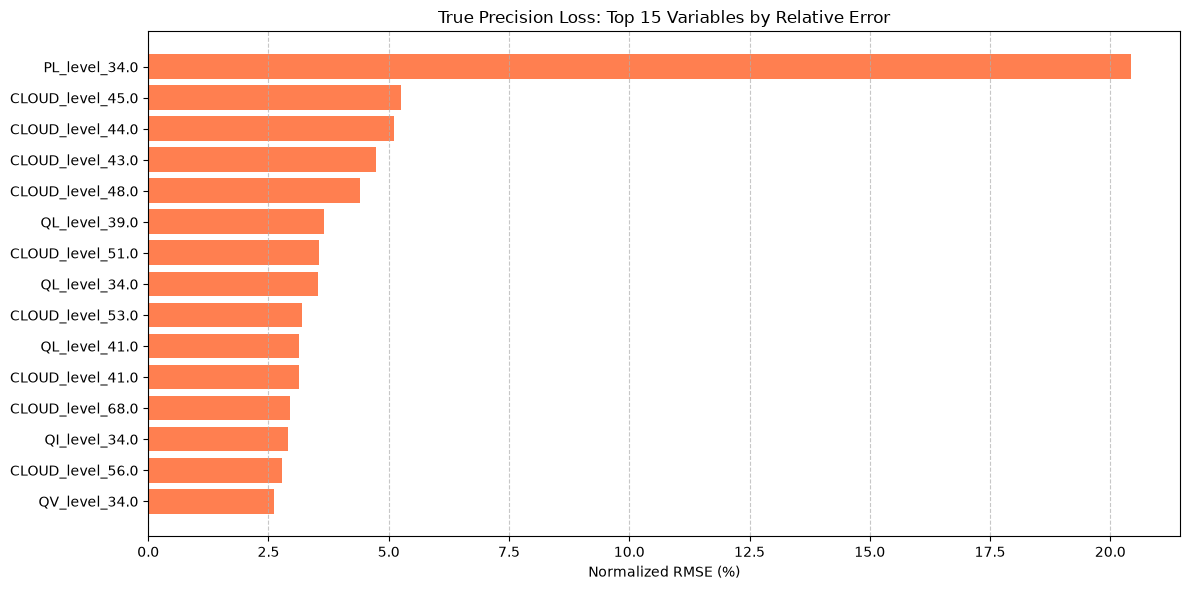

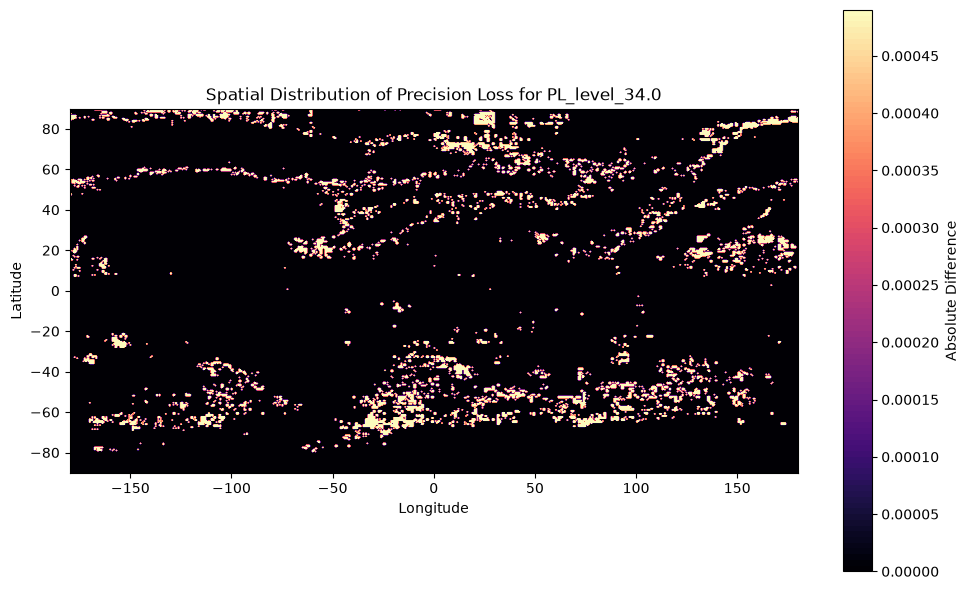

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate Ranges and Normalized RMSE (NRMSE) for fair comparison
relative_results = []

for i, var_name in enumerate(variable_names):
    var_fp32 = out_fp32[0, i]
    var_mp = out_mp[0, i]
    
    # Calculate min, max, and range based on the true FP32 baseline
    v_min = float(np.min(var_fp32))
    v_max = float(np.max(var_fp32))
    var_range = v_max - v_min
    
    # Calculate raw RMSE
    rmse = np.sqrt(np.mean((var_fp32 - var_mp)**2))
    
    # Normalize by the range of the actual FP32 values (expressed as a percentage)
    nrmse = (rmse / var_range) * 100 if var_range > 0 else 0 
    
    relative_results.append({
        "Variable": var_name,
        "Min Value": v_min,
        "Max Value": v_max,
        "Range": var_range,
        "RMSE (Raw)": rmse,
        "NRMSE (%)": nrmse
    })

# Convert to DataFrame and sort by the highest relative error
df_rel = pd.DataFrame(relative_results)
df_rel_sorted = df_rel.sort_values(by="NRMSE (%)", ascending=False)
top_15 = df_rel_sorted.head(15)

# Print the detailed table
print("TOP 15 VARIABLES WITH HIGHEST NRMSE (%) AND THEIR DATA RANGES")
print("=" * 100)
print(top_15.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 100)

# 2. Plot 1: Top 15 Variables by Normalized Error
plt.figure(figsize=(12, 6))
plt.barh(top_15["Variable"][::-1], top_15["NRMSE (%)"][::-1], color='coral')
plt.xlabel('Normalized RMSE (%)')
plt.title('True Precision Loss: Top 15 Variables by Relative Error')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Plot 2: Spatial Heatmap of the Worst Offender
worst_var_name = top_15.iloc[0]["Variable"]
worst_var_idx = variable_names.index(worst_var_name)

# Calculate spatial absolute difference
spatial_diff = np.abs(out_fp32[0, worst_var_idx] - out_mp[0, worst_var_idx])

lat = np.linspace(-90, 90, out_fp32.shape[-2])
lon = np.linspace(-180, 180, out_fp32.shape[-1])
X, Y = np.meshgrid(lon, lat)

plt.figure(figsize=(10, 6))
contour = plt.contourf(X, Y, spatial_diff, 100, cmap='magma')
plt.colorbar(contour, label='Absolute Difference')
plt.gca().set_aspect("equal")
plt.title(f'Spatial Distribution of Precision Loss for {worst_var_name}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import pandas as pd

# Assuming relative_results was generated from the previous script
df_rel = pd.DataFrame(relative_results)

# The NRMSE in the dataframe is a percentage (e.g., 5.0 for 5%). 
# We convert it back to a fraction (0.05) for the accuracy calculation.
nrmse_fractions = df_rel["NRMSE (%)"] / 100.0

# Calculate the mean relative error across all atmospheric variables
average_relative_error = np.mean(nrmse_fractions)

# Calculate relative accuracy (FP32 baseline = 1.0)
overall_relative_accuracy = 1.0 - average_relative_error

# Convert to a percentage for readability
overall_accuracy_percentage = overall_relative_accuracy * 100

print("=" * 60)
print(f"{'MIXED PRECISION RELATIVE ACCURACY':^60}")
print("=" * 60)
print(f"FP32 Baseline Accuracy : 1.000000 (100.00%)")
print(f"Average Relative Error : {average_relative_error:.6f} ({average_relative_error * 100:.2f}%)")
print("-" * 60)
print(f"Overall Model Accuracy : {overall_relative_accuracy:.6f} ({overall_accuracy_percentage:.2f}%)")
print("=" * 60)

             MIXED PRECISION RELATIVE ACCURACY              
FP32 Baseline Accuracy : 1.000000 (100.00%)
Average Relative Error : 0.011272 (1.13%)
------------------------------------------------------------
Overall Model Accuracy : 0.988728 (98.87%)
